In [13]:
from pybaseball import statcast_single_game, playerid_reverse_lookup
import matplotlib.pyplot as plt
import statsapi as MLB_API
import pandas as pd

## Get Team and Game Info

In [14]:
print("lookup team")
tor = MLB_API.lookup_team("tor")
last_game_id = MLB_API.last_game(tor[0]['id'])
game_info:pd.DataFrame = statcast_single_game(last_game_id)
if not game_info.empty:
    print("got game👍")
else:
    print("get game failed :(")
    raise RuntimeError("failed to get game")

lookup team
got game👍


c:\Python313\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)


## Game Info

In [15]:
keys = game_info.keys()

with open('game_info_keys.txt', 'w') as f:
    for key in keys:
        f.write(f"{key}\n")

# Write selected columns to CSV (requested columns)
columns_to_write = [
    'pitch_type', 'release_speed', 'player_name', 'pitcher', 'p_throws', 'balls', 'strikes', 'inning',
    'inning_topbot', 'launch_angle', 'lauch_speed', 'effective_speed', 'iso_value', 'woba_value',
    'estimated_woba_using_speedangle', 'estimated_ba_using_speedangle', 'estimated_slg_using_speedangle',
    'delta_pitcher_run_exp', 'hyper_speed', 'events', 'n_priorpa_thisgame_player_at_bat', 'zone',
]
# Keep only columns that actually exist in the DataFrame
cols_present = [c for c in columns_to_write if c in game_info.columns]
# If the user wrote 'lauch_speed' but the DataFrame has 'launch_speed', prefer the correct name
if 'lauch_speed' in columns_to_write and 'lauch_speed' not in cols_present and 'launch_speed' in game_info.columns:
    # insert launch_speed where lauch_speed was requested
    insert_pos = columns_to_write.index('lauch_speed') if 'lauch_speed' in columns_to_write else len(cols_present)
    cols_present.insert(min(insert_pos, len(cols_present)), 'launch_speed')
# Deduplicate while preserving order
seen = set()
cols_present = [c for c in cols_present if not (c in seen or seen.add(c))]
if cols_present:
    game_info.loc[:, cols_present].to_csv('game_info_selected.csv', index=False, encoding='utf-8')
    print(f'Wrote {len(cols_present)} columns to game_info_selected.csv')
else:
    print('No requested columns found in game_info; CSV not written.')
        
home_team = game_info.iloc[0]['home_team']
away_team = game_info.iloc[0]['away_team']

print(f"Game Date: {game_info.iloc[0]['game_date']}")
print(f"{away_team} @ {home_team}")
print(f"{game_info['post_away_score'].max()} - {game_info['post_home_score'].max()}")
if not game_info.iloc[0]['inning'] == 9:
    print(f"Extra innings - ({game_info.iloc[0]['inning']})")

Wrote 22 columns to game_info_selected.csv
Game Date: 2026-04-05 00:00:00
TOR @ CWS
0 - 3


## Batter Info

In [16]:
batters = game_info['batter'].unique().tolist()

print(f"Total Unique Batters: {len(batters)}")

names:pd.DataFrame = playerid_reverse_lookup(batters, key_type='mlbam')
batters:tuple[int, str, str] = list(zip(names['key_mlbam'], names['name_first'], names['name_last']))

batter_info = []

for batter in batters:
    woba = float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_woba_using_speedangle'].mean(), 3))
    xslg = float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_slg_using_speedangle'].mean(), 3))
    if pd.isna(woba):
        woba = 0
    if pd.isna(xslg):
        xslg = 0
    b_data = {
        'id': batter[0],
        'first_name': batter[1].capitalize(),
        'last_name': batter[2].capitalize(),
        'total_estimated_woba': float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_woba_using_speedangle'].sum(), 3)),
        'total_estimated_slg': float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_slg_using_speedangle'].sum(), 3)),
        'total_wops': float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_woba_using_speedangle'].sum(), 3)) +
        float(round(game_info.loc[game_info['batter'] == batter[0], 'estimated_slg_using_speedangle'].sum(), 3)),
        'home_team': game_info.loc[game_info['batter'] == batter[0], 'inning_topbot'].iloc[0] == 'Bot',
        'woba':woba,
        'xslg':xslg,
        'wops': round(woba + xslg, 3)
    }
    batter_info.append(b_data)
    print(f"---{b_data['last_name']}, {b_data['first_name']}---")
    print(f"Team = {home_team if b_data['home_team'] else away_team}")
    print(f"Estimated times reaching base: {b_data['total_estimated_woba']}")
    print(f"Estimated total bases: {b_data['total_estimated_slg']}")
    print(f"Total wOPS: {b_data['total_wops']}")
    print(f'wOBA: {b_data['woba']}')
    print(f'xSLG: {b_data['xslg']}')
    print(f'wOPS: {b_data['wops']}')

Total Unique Batters: 21
---Lukes, Nathan---
Team = TOR
Estimated times reaching base: 0.675
Estimated total bases: 0.831
Total wOPS: 1.506
wOBA: 0.169
xSLG: 0.277
wOPS: 0.446
---Barger, Addison---
Team = TOR
Estimated times reaching base: 0.334
Estimated total bases: 0.412
Total wOPS: 0.746
wOBA: 0.111
xSLG: 0.137
wOPS: 0.248
---Benintendi, Andrew---
Team = CWS
Estimated times reaching base: 0.045
Estimated total bases: 0.079
Total wOPS: 0.124
wOBA: 0.045
xSLG: 0.079
wOPS: 0.124
---Quero, Edgar---
Team = CWS
Estimated times reaching base: 1.675
Estimated total bases: 0.327
Total wOPS: 2.0020000000000002
wOBA: 0.419
xSLG: 0.164
wOPS: 0.583
---Meidroth, Chase---
Team = CWS
Estimated times reaching base: 0.482
Estimated total bases: 0.676
Total wOPS: 1.158
wOBA: 0.121
xSLG: 0.225
wOPS: 0.346
---Clement, Ernie---
Team = TOR
Estimated times reaching base: 1.657
Estimated total bases: 2.08
Total wOPS: 3.737
wOBA: 0.414
xSLG: 0.693
wOPS: 1.107
---Varsho, Daulton---
Team = TOR
Estimated times

## Team Splits and Game Predictions

In [31]:
home_info = []
away_info = []
for batter in batter_info:
    if batter['home_team']:
        home_info.append(batter)
    else:
        away_info.append(batter)

def print_team_info(team_info:list, home_away:bool) -> None:
    print(f'-----{home_team if home_away else away_team} Team Info-----')
    print(f'Estimated times reaching base: {sum(batter['total_estimated_woba'] for batter in team_info)}')
    print(f'Estimated bases: {sum(batter['total_estimated_slg'] for batter in team_info)}')
    print(f'Team wOBA: {round(sum(batter['woba'] for batter in team_info) / len(team_info), 3)}')
    print(f'Team xSLG: {round(sum(batter['xslg'] for batter in team_info) / len(team_info), 3)}')
    print(f'Team wOPS: {round(sum(batter['wops'] for batter in team_info) / len(team_info), 3)}')
    print('\n')

print_team_info(home_info, True)
print_team_info(away_info, False)

print('-----Game Analysis-----')
home_bat_dtwom = sum(batter['total_estimated_slg'] for batter in home_info) / (sum(batter['total_estimated_slg'] for batter in home_info) + sum(batter['total_estimated_slg'] for batter in away_info)) * 100
away_bat_dtwom = 100 - home_bat_dtwom
print(f'{home_team} Deserve-to-Win-O-Meter: {round(home_bat_dtwom, 2)}%')
print(f'{away_team} Deserve-to-Win-O-Meter: {round(away_bat_dtwom, 2)}%')

-----CWS Team Info-----
Estimated times reaching base: 9.562
Estimated bases: 9.789
Team wOBA: 0.304
Team xSLG: 0.4
Team wOPS: 0.704


-----TOR Team Info-----
Estimated times reaching base: 8.432
Estimated bases: 9.155
Team wOBA: 0.277
Team xSLG: 0.404
Team wOPS: 0.682


-----Game Analysis-----
CWS Deserve-to-Win-O-Meter: 51.67%
TOR Deserve-to-Win-O-Meter: 48.33%


## Visualizations

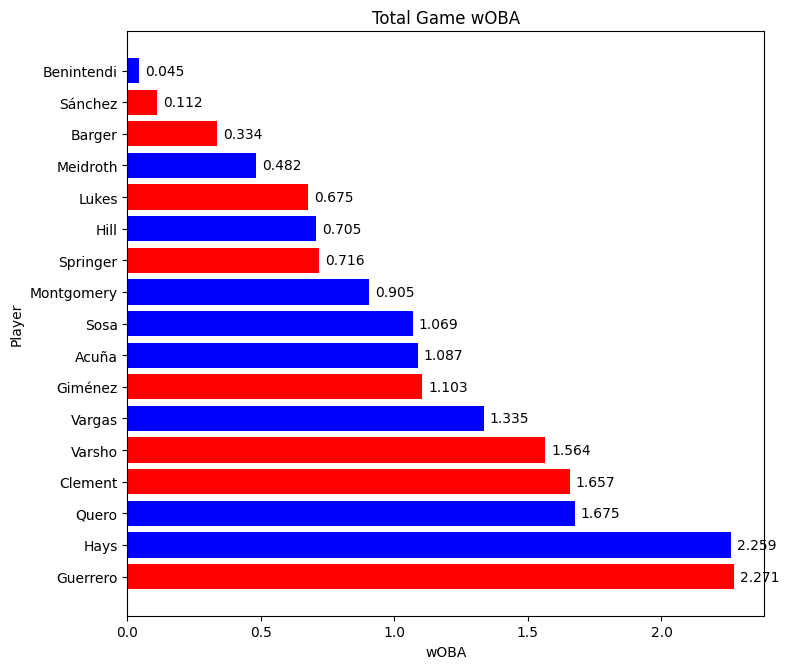

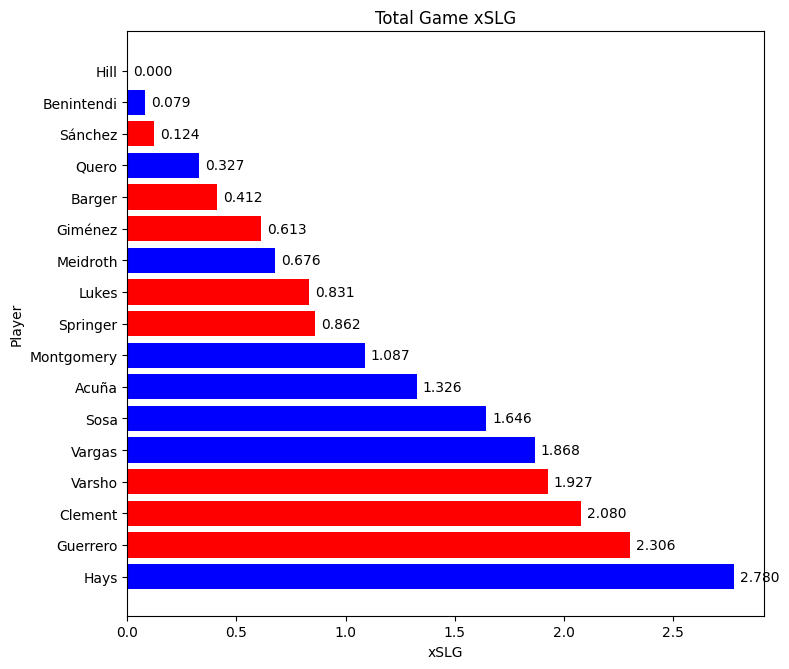

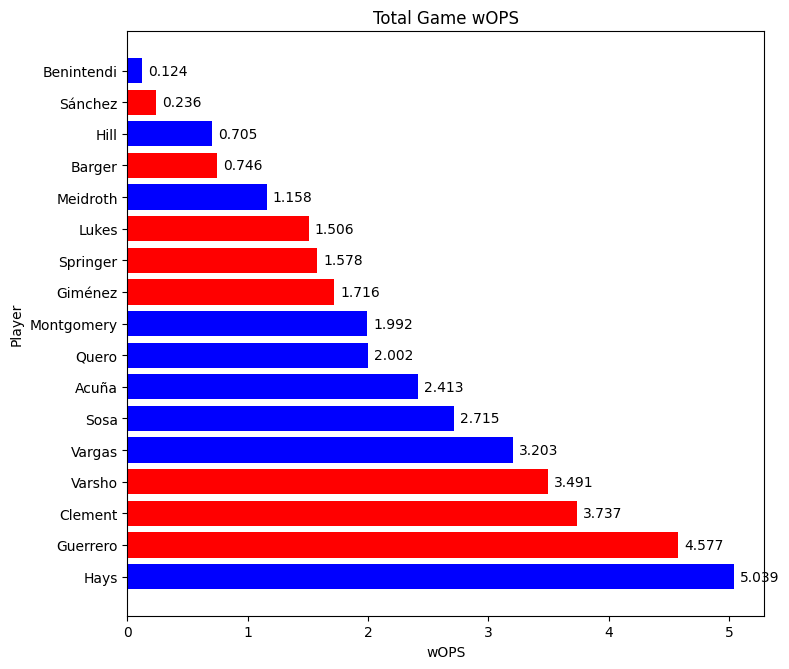

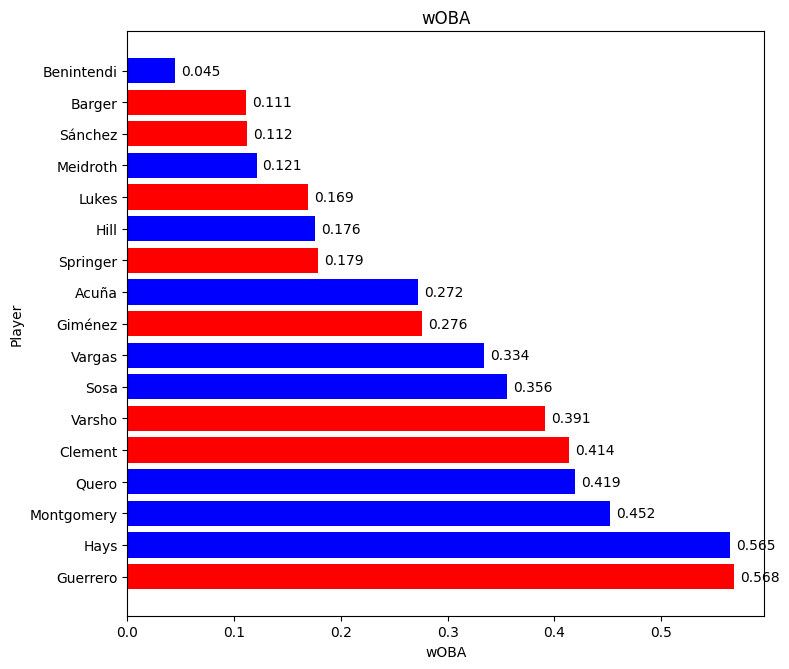

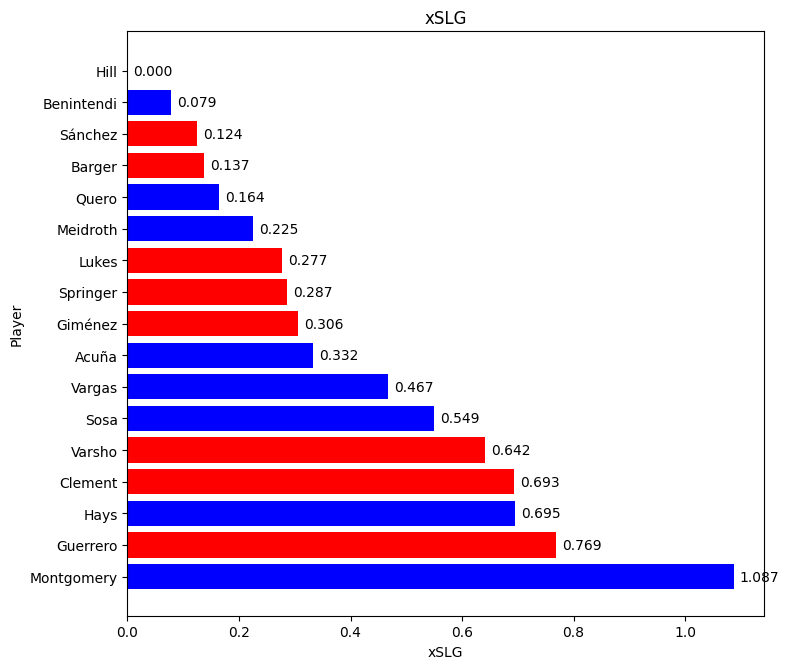

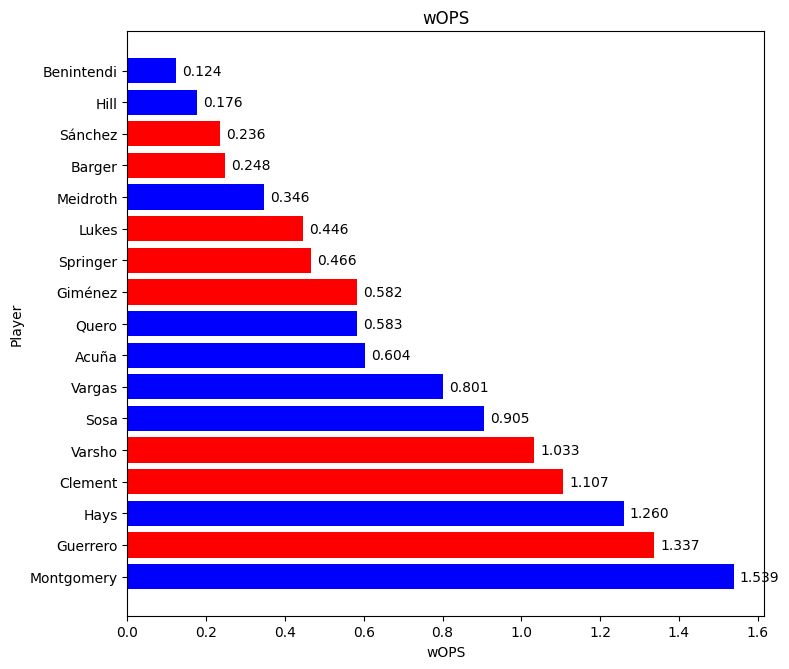

In [18]:
#Totals Graphs

#wOBA graph
sorted_batters = sorted(batter_info, key=lambda b: b['total_estimated_woba'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['total_estimated_woba'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOBA')
plt.ylabel('Player')
plt.title('Total Game wOBA')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#xSLG graph
sorted_batters = sorted(batter_info, key=lambda b: b['total_estimated_slg'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['total_estimated_slg'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('xSLG')
plt.ylabel('Player')
plt.title('Total Game xSLG')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#wOPS graph
sorted_batters = sorted(batter_info, key=lambda b: b['total_wops'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['total_wops'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]
plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOPS')
plt.ylabel('Player')
plt.title('Total Game wOPS')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#Graphs for Averages

#wOBA graph
sorted_batters = sorted(batter_info, key=lambda b: b['woba'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['woba'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOBA')
plt.ylabel('Player')
plt.title('wOBA')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#xSLG graph
sorted_batters = sorted(batter_info, key=lambda b: b['xslg'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['xslg'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]

plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('xSLG')
plt.ylabel('Player')
plt.title('xSLG')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

#wOPS graph
sorted_batters = sorted(batter_info, key=lambda b: b['wops'])
categories = [b['last_name'] for b in sorted_batters]
values = [b['wops'] for b in sorted_batters]
colors = ['blue' if b['home_team'] else 'red' for b in sorted_batters]
plt.figure(figsize=(8, max(4, len(categories) * 0.4)))
bars = plt.barh(categories, values, color=colors)
plt.xlabel('wOPS')
plt.ylabel('Player')
plt.title('wOPS')
plt.gca().invert_yaxis()
for bar, v in zip(bars, values):
    plt.text(bar.get_width() + (max(values) if values else 0) * 0.01, bar.get_y() + bar.get_height() / 2, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

## Pitching Above Expected

In [28]:
#take all the game data
# seperate into home pitching (top of the inning)

pitchers = game_info['pitcher'].unique().tolist()

home_pitchers:list = game_info.loc[game_info['inning_topbot'] == 'Top', 'pitcher'].unique().tolist()
away_pitchers:list = game_info.loc[game_info['inning_topbot'] == 'Bot', 'pitcher'].unique().tolist()

hp_df:pd.DataFrame = playerid_reverse_lookup(home_pitchers, key_type='mlbam')
ap_df:pd.DataFrame = playerid_reverse_lookup(away_pitchers, key_type='mlbam')

hp_tuples:list[tuple[int, str, str]] = list(zip(hp_df['key_mlbam'].tolist(), hp_df['name_last'].tolist(), hp_df['name_first'].tolist()))
ap_tuples:list[tuple[int, str, str]] = list(zip(ap_df['key_mlbam'].tolist(), ap_df['name_last'].tolist(), ap_df['name_first'].tolist()))

print(f'{home_team} # of pitchers: {len(home_pitchers)}')
print(f'{away_team} # of pitchers: {len(away_pitchers)}')

home_pitching_exp_runs:float = round(game_info.loc[game_info['inning_topbot'] == 'Top', 'delta_pitcher_run_exp'].sum(), 3)
away_pitching_exp_runs:float = round(game_info.loc[game_info['inning_topbot'] == 'Bot', 'delta_pitcher_run_exp'].sum(), 3)

print(f'{home_team} Pitching expected runs: {home_pitching_exp_runs}')
print(f'{away_team} Pitching expected runs: {away_pitching_exp_runs}')

print("Individual Home Pitchers Impact")
for p in hp_tuples:
    print(f'{p[1].capitalize()} {p[2].capitalize()} - {round(game_info.loc[game_info['pitcher'] == p[0], 'delta_pitcher_run_exp'].sum(), 3)} expected runs')

print("Individual Away Pitchers Impact")
for p in ap_tuples:
    print(f'{p[1].capitalize()} {p[2].capitalize()} - {round(game_info.loc[game_info['pitcher'] == p[0], 'delta_pitcher_run_exp'].sum(), 3)} expected runs')

print("Pitching above expected:")
home_pitch_above_exp = round(home_pitching_exp_runs - game_info['post_home_score'].max(), 3)
away_pitch_above_exp = round(away_pitching_exp_runs - game_info['post_away_score'].max(), 3)
print(f'{home_team}: {home_pitch_above_exp}')
print(f'{away_team}: {away_pitch_above_exp}')

home_pitch_dtwom = round((home_pitch_above_exp / (home_pitch_above_exp + away_pitch_above_exp) * 100), 2)
away_pitch_dtwom = round((away_pitch_above_exp / (home_pitch_above_exp + away_pitch_above_exp) * 100), 2)
print(f"{home_team} deserve to win (pitching): {home_pitch_dtwom}%")
print(f"{away_team} deserve to win (pitching): {away_pitch_dtwom}%")

CWS # of pitchers: 4
TOR # of pitchers: 4
CWS Pitching expected runs: 3.343
TOR Pitching expected runs: 0.217
Individual Home Pitchers Impact
Hudson Bryan - -0.399 expected runs
Martin Davis - 2.358 expected runs
Murphy Chris - 0.328 expected runs
Leasure Jordan - 1.056 expected runs
Individual Away Pitchers Impact
Lauer Eric - -1.193 expected runs
Voth Austin - -0.329 expected runs
Mantiply Joe - 1.042 expected runs
Pitching above expected:
CWS: 0.343
TOR: 0.217
CWS deserve to win (pitching): 61.25%
TOR deserve to win (pitching): 38.75%


## Deserve-to-Win-O-Meter

In [33]:
home_dtwom = round((home_bat_dtwom + home_pitch_dtwom) / 2, 2)
away_dtwom = round((away_bat_dtwom + away_pitch_dtwom) / 2, 2)
print(f'{home_team} Deserve-to-Win-O-Meter: {home_dtwom}%')
print(f'{away_team} Deserve-to-Win-O-Meter: {away_dtwom}%')

print(f'{home_team if away_dtwom < 50 else away_team} deserved to win that game')

CWS Deserve-to-Win-O-Meter: 56.46%
TOR Deserve-to-Win-O-Meter: 43.54%
CWS deserved to win that game
